## IMPORTS

In [83]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.patches import Patch
from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

## READING DATA

In [84]:
highways = gpd.read_file("data/Highways%3A_Traffic_Counts/Highways%3A_Traffic_Counts.shp")
major_roads = gpd.read_file("data/Major_Roads/Major_Roads.shp")
vtds = gpd.read_file("data/co.shp")

## MAPS

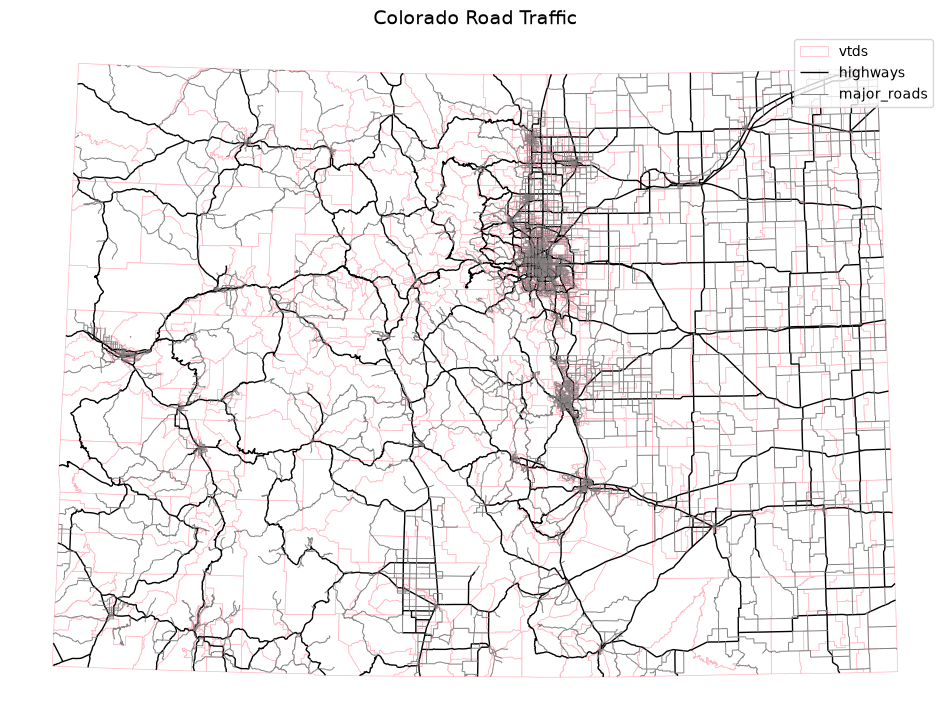

In [85]:
fig, ax = plt.subplots(figsize=(12, 10))

vtds.plot(ax=ax, color="white", edgecolor="lightpink", linewidth=0.5, label = 'vtds')
highways.plot(ax=ax, color="black", linewidth=1, label = 'highways')
major_roads.plot(ax=ax, color="grey", linewidth=0.7, label = 'major_roads')

ax.set_title("Colorado Road Traffic", fontsize=14)
ax.legend()
ax.axis("off")
plt.show()


## DEBUGGING

In [86]:
#print(highways.columns)
#print(highways['COUNTSTATI'])
#print(major_roads.columns)
#print(major_roads['COUNTSTATI'])
matches = list(set(highways.columns) & set(major_roads.columns))
print(matches)

['Shape__Len', 'AADTDERIV', 'AADTYR', 'RUNLENGT_1', 'AADT', 'COUNTSTATI', 'RUNLENGTH_', 'ROUTE', 'geometry', 'OBJECTID']


## COLUMNS WE WANT TO USE  (I THINK)
#### - AADT
#### - RUNLENGTH_FROM
#### - RUNLENGTH_TO 


## MERGING DATASETS

In [87]:
all_roads = pd.concat([highways, major_roads], ignore_index=True)
print(all_roads)

       OBJECTID        ROUTE    REFPT  ENDREFPT  LENGTH_ UPDATEYR      AADT  \
0             1         285D  261.185   261.716    0.527     2024   54000.0   
1             2         009C   87.000    87.270    0.353     2024   11000.0   
2             3         025A  205.057   205.919    0.834     2024  214000.0   
3             4         006J  424.964   431.335    6.408     2024    2300.0   
4             5         036D   91.336    95.000    3.655     2024    4800.0   
...         ...          ...      ...       ...      ...      ...       ...   
46478     43219           36      NaN       NaN      NaN      NaN   30000.0   
46479     43220  17TH     AV      NaN       NaN      NaN      NaN   11000.0   
46480     43221  MISSISSIPAV      NaN       NaN      NaN      NaN   18000.0   
46481     43222           33      NaN       NaN      NaN      NaN    2000.0   
46482     43223            3      NaN       NaN      NaN      NaN       NaN   

      AADTYR COUNTYEAR AADTDERIV  ...  URBAN  POPUL

## POTENTIAL IR SCORING FUNCTION

In [88]:
def calculate_ir(partiton):
    pass